In [1]:
import requests, time
import pandas as pd, numpy as np

In [3]:
import requests

headers = {"User-Agent": "MyFoodApp/1.0"}

all_products = []
page = 1

while len(all_products) < 500:

    url = f"https://world.openfoodfacts.org/api/v2/search?categories=chocolates&fields=code,product_name,brands,nutriments&page_size=100&page={page}"

    response = requests.get(url, headers=headers)

    if response.status_code != 200:
        print("Error:", response.status_code)
        break

    data = response.json()

    products = data.get("products", [])

    # Stop if no more products
    if not products:
        break

    all_products.extend(products)

    print(f"Fetched {len(products)} products from page {page}")
    print(f"Total products collected: {len(all_products)}")

    page += 1

# Keep only first 500
all_products = all_products[:500]

print("Final total:", len(all_products))

Fetched 100 products from page 1
Total products collected: 100
Fetched 100 products from page 2
Total products collected: 200
Fetched 100 products from page 3
Total products collected: 300
Fetched 100 products from page 4
Total products collected: 400
Fetched 100 products from page 5
Total products collected: 500
Final total: 500


In [4]:
import pandas as pd

df = pd.DataFrame(all_products)
display(df.head())

,brands,code,nutriments,nutrition_data,nutrition_data_prepared_per,product_name,nutrition_data_per,nutriments_estimated,serving_quantity,nutrition_data_prepared
0,Milky Food Professional,6111246721261,"{'added-sugars': 0, 'added-sugars_100g': 0, 'a...",on,100g,Fromage Blanc Nature,NaN,NaN,NaN,NaN
1,سيدي علي,6111035000430,"{'added-sugars': 0, 'added-sugars_100g': 0, 'a...",on,100g,Sidi Ali,100ml,NaN,NaN,NaN
2,Jaouda,6111242100992,"{'added-sugars': 10, 'added-sugars_100g': 10, ...",on,100g,Perly,NaN,NaN,NaN,NaN
3,sidi ali,6111035000058,"{'added-sugars': 0, 'added-sugars_100g': 0, 'a...",on,100g,Eau minérale naturelle,NaN,"{'alcohol_100g': 0, 'beta-carotene_100g': 0, '...",NaN,NaN
4,Sidi Ali,6111035002175,"{'added-sugars': 0.0, 'added-sugars_100g': 0, ...",on,100g,Sidi Ali,100ml,NaN,NaN,NaN


In [5]:
# Check for missing values
missing_values = df.isnull().sum()
print("Missing values per column:")
print(missing_values)

Missing values per column:
brands                          12
code                             0
nutriments                       2
nutrition_data                  17
nutrition_data_prepared_per      2
product_name                     5
nutrition_data_per             144
nutriments_estimated           309
serving_quantity               500
nutrition_data_prepared        485
dtype: int64


In [6]:
# Handle missing values by imputing
df['brands'] = df['brands'].fillna('Unknown Brand')
df['product_name'] = df['product_name'].fillna('Unknown Product')

# Verify that missing values have been handled
missing_values_after = df.isnull().sum()
print("\nMissing values per column after handling:")
print(missing_values_after)


Missing values per column after handling:
brands                           0
code                             0
nutriments                       2
nutrition_data                  17
nutrition_data_prepared_per      2
product_name                     0
nutrition_data_per             144
nutriments_estimated           309
serving_quantity               500
nutrition_data_prepared        485
dtype: int64


In [9]:
import numpy as np
import pandas as pd

nutrient_keys = [
    'energy-kcal_value', 'energy-kj_value', 'carbohydrates_value', 
    'sugars_value', 'fat_value', 'saturated-fat_value', 
    'proteins_value', 'fiber_value', 'salt_value', 
    'sodium_value', 'nova-group', 'fruits-vegetables-nuts-estimate-from-ingredients_100g'
]

for key in nutrient_keys:
    # Added a conditional check: only call .get() if x is a dictionary/not null
    df[key] = df['nutriments'].apply(lambda x: x.get(key, np.nan) if isinstance(x, dict) else np.nan)

display(df.head())

,brands,code,nutriments,nutrition_data,nutrition_data_prepared_per,product_name,nutrition_data_per,nutriments_estimated,serving_quantity,nutrition_data_prepared,...,carbohydrates_value,sugars_value,fat_value,saturated-fat_value,proteins_value,fiber_value,salt_value,sodium_value,nova-group,fruits-vegetables-nuts-estimate-from-ingredients_100g
0,Milky Food Professional,6111246721261,"{'added-sugars': 0, 'added-sugars_100g': 0, 'a...",on,100g,Fromage Blanc Nature,NaN,NaN,NaN,NaN,...,10.0,4.0,11.0,7.15,5.0,0.0,0.100,0.1000,3.0,0.00
1,سيدي علي,6111035000430,"{'added-sugars': 0, 'added-sugars_100g': 0, 'a...",on,100g,Sidi Ali,100ml,NaN,NaN,NaN,...,4.2,1.4,0.0,0.00,0.0,0.0,0.000,0.0000,NaN,0.00
2,Jaouda,6111242100992,"{'added-sugars': 10, 'added-sugars_100g': 10, ...",on,100g,Perly,NaN,NaN,NaN,NaN,...,9.4,9.4,3.0,0.00,8.0,0.0,0.000,0.0000,3.0,6.85
3,sidi ali,6111035000058,"{'added-sugars': 0, 'added-sugars_100g': 0, 'a...",on,100g,Eau minérale naturelle,NaN,"{'alcohol_100g': 0, 'beta-carotene_100g': 0, '...",NaN,NaN,...,0.0,NaN,0.0,NaN,0.0,NaN,0.006,0.0024,1.0,0.00
4,Sidi Ali,6111035002175,"{'added-sugars': 0.0, 'added-sugars_100g': 0, ...",on,100g,Sidi Ali,100ml,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.065,0.0260,1.0,0.00


In [11]:
nutrient_keys = [
    'energy-kcal_value',
    'energy-kj_value',
    'carbohydrates_value',
    'sugars_value',
    'fat_value',
    'saturated-fat_value',
    'proteins_value',
    'fiber_value',
    'salt_value',
    'sodium_value',
    'nova-group',
    'fruits-vegetables-nuts-estimate-from-ingredients_100g'
]

for key in nutrient_keys:
    df[key] = pd.to_numeric(df[key], errors='coerce')

display(df.head())

,brands,code,nutriments,nutrition_data,nutrition_data_prepared_per,product_name,nutrition_data_per,nutriments_estimated,serving_quantity,nutrition_data_prepared,...,carbohydrates_value,sugars_value,fat_value,saturated-fat_value,proteins_value,fiber_value,salt_value,sodium_value,nova-group,fruits-vegetables-nuts-estimate-from-ingredients_100g
0,Milky Food Professional,6111246721261,"{'added-sugars': 0, 'added-sugars_100g': 0, 'a...",on,100g,Fromage Blanc Nature,NaN,NaN,NaN,NaN,...,10.0,4.0,11.0,7.15,5.0,0.0,0.100,0.1000,3.0,0.00
1,سيدي علي,6111035000430,"{'added-sugars': 0, 'added-sugars_100g': 0, 'a...",on,100g,Sidi Ali,100ml,NaN,NaN,NaN,...,4.2,1.4,0.0,0.00,0.0,0.0,0.000,0.0000,NaN,0.00
2,Jaouda,6111242100992,"{'added-sugars': 10, 'added-sugars_100g': 10, ...",on,100g,Perly,NaN,NaN,NaN,NaN,...,9.4,9.4,3.0,0.00,8.0,0.0,0.000,0.0000,3.0,6.85
3,sidi ali,6111035000058,"{'added-sugars': 0, 'added-sugars_100g': 0, 'a...",on,100g,Eau minérale naturelle,NaN,"{'alcohol_100g': 0, 'beta-carotene_100g': 0, '...",NaN,NaN,...,0.0,NaN,0.0,NaN,0.0,NaN,0.006,0.0024,1.0,0.00
4,Sidi Ali,6111035002175,"{'added-sugars': 0.0, 'added-sugars_100g': 0, ...",on,100g,Sidi Ali,100ml,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.065,0.0260,1.0,0.00


In [13]:
nutrient_keys = [
    'energy-kcal_value',
    'energy-kj_value',
    'carbohydrates_value',
    'sugars_value',
    'fat_value',
    'saturated-fat_value',
    'proteins_value',
    'fiber_value',
    'salt_value',
    'sodium_value',
    'nova-group',
    'fruits-vegetables-nuts-estimate-from-ingredients_100g'
]

for key in nutrient_keys:
    median_value = df[key].median()
    df[key] = df[key].fillna(median_value)

# Verify that missing values have been handled
missing_values_after_imputation = df[nutrient_keys].isnull().sum()
print("\nMissing values per nutrient column after imputation:")
print(missing_values_after_imputation)


Missing values per nutrient column after imputation:
energy-kcal_value                                        0
energy-kj_value                                          0
carbohydrates_value                                      0
sugars_value                                             0
fat_value                                                0
saturated-fat_value                                      0
proteins_value                                           0
fiber_value                                              0
salt_value                                               0
sodium_value                                             0
nova-group                                               0
fruits-vegetables-nuts-estimate-from-ingredients_100g    0
dtype: int64


In [14]:
df['sugar_to_carb_ratio'] = df['sugars_value'] / df['carbohydrates_value']
df['sugar_to_carb_ratio'] = df['sugar_to_carb_ratio'].replace([np.inf, -np.inf], np.nan)
display(df.head())

,brands,code,nutriments,nutrition_data,nutrition_data_prepared_per,product_name,nutrition_data_per,nutriments_estimated,serving_quantity,nutrition_data_prepared,...,sugars_value,fat_value,saturated-fat_value,proteins_value,fiber_value,salt_value,sodium_value,nova-group,fruits-vegetables-nuts-estimate-from-ingredients_100g,sugar_to_carb_ratio
0,Milky Food Professional,6111246721261,"{'added-sugars': 0, 'added-sugars_100g': 0, 'a...",on,100g,Fromage Blanc Nature,NaN,NaN,NaN,NaN,...,4.0,11.00,7.15000,5.0,0.0,0.100,0.1000,3.0,0.00,0.400000
1,سيدي علي,6111035000430,"{'added-sugars': 0, 'added-sugars_100g': 0, 'a...",on,100g,Sidi Ali,100ml,NaN,NaN,NaN,...,1.4,0.00,0.00000,0.0,0.0,0.000,0.0000,4.0,0.00,0.333333
2,Jaouda,6111242100992,"{'added-sugars': 10, 'added-sugars_100g': 10, ...",on,100g,Perly,NaN,NaN,NaN,NaN,...,9.4,3.00,0.00000,8.0,0.0,0.000,0.0000,3.0,6.85,1.000000
3,sidi ali,6111035000058,"{'added-sugars': 0, 'added-sugars_100g': 0, 'a...",on,100g,Eau minérale naturelle,NaN,"{'alcohol_100g': 0, 'beta-carotene_100g': 0, '...",NaN,NaN,...,4.6,0.00,1.61604,0.0,3.5,0.006,0.0024,1.0,0.00,NaN
4,Sidi Ali,6111035002175,"{'added-sugars': 0.0, 'added-sugars_100g': 0, ...",on,100g,Sidi Ali,100ml,NaN,NaN,NaN,...,4.6,9.55,1.61604,6.9,3.5,0.065,0.0260,1.0,0.00,0.198276


In [15]:
def categorize_calories(kcal):
    if pd.isna(kcal):
        return 'Unknown'
    elif kcal < 100:
        return 'Low'
    elif kcal < 400:
        return 'Medium'
    else:
        return 'High'

df['calorie_category'] = df['energy-kcal_value'].apply(categorize_calories)

display(df.head())

,brands,code,nutriments,nutrition_data,nutrition_data_prepared_per,product_name,nutrition_data_per,nutriments_estimated,serving_quantity,nutrition_data_prepared,...,fat_value,saturated-fat_value,proteins_value,fiber_value,salt_value,sodium_value,nova-group,fruits-vegetables-nuts-estimate-from-ingredients_100g,sugar_to_carb_ratio,calorie_category
0,Milky Food Professional,6111246721261,"{'added-sugars': 0, 'added-sugars_100g': 0, 'a...",on,100g,Fromage Blanc Nature,NaN,NaN,NaN,NaN,...,11.00,7.15000,5.0,0.0,0.100,0.1000,3.0,0.00,0.400000,Medium
1,سيدي علي,6111035000430,"{'added-sugars': 0, 'added-sugars_100g': 0, 'a...",on,100g,Sidi Ali,100ml,NaN,NaN,NaN,...,0.00,0.00000,0.0,0.0,0.000,0.0000,4.0,0.00,0.333333,Low
2,Jaouda,6111242100992,"{'added-sugars': 10, 'added-sugars_100g': 10, ...",on,100g,Perly,NaN,NaN,NaN,NaN,...,3.00,0.00000,8.0,0.0,0.000,0.0000,3.0,6.85,1.000000,Low
3,sidi ali,6111035000058,"{'added-sugars': 0, 'added-sugars_100g': 0, 'a...",on,100g,Eau minérale naturelle,NaN,"{'alcohol_100g': 0, 'beta-carotene_100g': 0, '...",NaN,NaN,...,0.00,1.61604,0.0,3.5,0.006,0.0024,1.0,0.00,NaN,Low
4,Sidi Ali,6111035002175,"{'added-sugars': 0.0, 'added-sugars_100g': 0, ...",on,100g,Sidi Ali,100ml,NaN,NaN,NaN,...,9.55,1.61604,6.9,3.5,0.065,0.0260,1.0,0.00,0.198276,Medium


In [16]:
def categorize_sugar(sugar_value):
    if pd.isna(sugar_value):
        return 'Unknown'
    elif sugar_value < 5:
        return 'Low Sugar'
    elif sugar_value < 15:
        return 'Medium Sugar'
    else:
        return 'High Sugar'

df['sugar_category'] = df['sugars_value'].apply(categorize_sugar)

display(df.head())

,brands,code,nutriments,nutrition_data,nutrition_data_prepared_per,product_name,nutrition_data_per,nutriments_estimated,serving_quantity,nutrition_data_prepared,...,saturated-fat_value,proteins_value,fiber_value,salt_value,sodium_value,nova-group,fruits-vegetables-nuts-estimate-from-ingredients_100g,sugar_to_carb_ratio,calorie_category,sugar_category
0,Milky Food Professional,6111246721261,"{'added-sugars': 0, 'added-sugars_100g': 0, 'a...",on,100g,Fromage Blanc Nature,NaN,NaN,NaN,NaN,...,7.15000,5.0,0.0,0.100,0.1000,3.0,0.00,0.400000,Medium,Low Sugar
1,سيدي علي,6111035000430,"{'added-sugars': 0, 'added-sugars_100g': 0, 'a...",on,100g,Sidi Ali,100ml,NaN,NaN,NaN,...,0.00000,0.0,0.0,0.000,0.0000,4.0,0.00,0.333333,Low,Low Sugar
2,Jaouda,6111242100992,"{'added-sugars': 10, 'added-sugars_100g': 10, ...",on,100g,Perly,NaN,NaN,NaN,NaN,...,0.00000,8.0,0.0,0.000,0.0000,3.0,6.85,1.000000,Low,Medium Sugar
3,sidi ali,6111035000058,"{'added-sugars': 0, 'added-sugars_100g': 0, 'a...",on,100g,Eau minérale naturelle,NaN,"{'alcohol_100g': 0, 'beta-carotene_100g': 0, '...",NaN,NaN,...,1.61604,0.0,3.5,0.006,0.0024,1.0,0.00,NaN,Low,Low Sugar
4,Sidi Ali,6111035002175,"{'added-sugars': 0.0, 'added-sugars_100g': 0, ...",on,100g,Sidi Ali,100ml,NaN,NaN,NaN,...,1.61604,6.9,3.5,0.065,0.0260,1.0,0.00,0.198276,Medium,Low Sugar


In [17]:
def is_ultra_processed(nova_group):
    if nova_group == 4:
        return 1
    else:
        return 0

df['is_ultra_processed'] = df['nova-group'].apply(is_ultra_processed)

display(df.head())

,brands,code,nutriments,nutrition_data,nutrition_data_prepared_per,product_name,nutrition_data_per,nutriments_estimated,serving_quantity,nutrition_data_prepared,...,proteins_value,fiber_value,salt_value,sodium_value,nova-group,fruits-vegetables-nuts-estimate-from-ingredients_100g,sugar_to_carb_ratio,calorie_category,sugar_category,is_ultra_processed
0,Milky Food Professional,6111246721261,"{'added-sugars': 0, 'added-sugars_100g': 0, 'a...",on,100g,Fromage Blanc Nature,NaN,NaN,NaN,NaN,...,5.0,0.0,0.100,0.1000,3.0,0.00,0.400000,Medium,Low Sugar,0
1,سيدي علي,6111035000430,"{'added-sugars': 0, 'added-sugars_100g': 0, 'a...",on,100g,Sidi Ali,100ml,NaN,NaN,NaN,...,0.0,0.0,0.000,0.0000,4.0,0.00,0.333333,Low,Low Sugar,1
2,Jaouda,6111242100992,"{'added-sugars': 10, 'added-sugars_100g': 10, ...",on,100g,Perly,NaN,NaN,NaN,NaN,...,8.0,0.0,0.000,0.0000,3.0,6.85,1.000000,Low,Medium Sugar,0
3,sidi ali,6111035000058,"{'added-sugars': 0, 'added-sugars_100g': 0, 'a...",on,100g,Eau minérale naturelle,NaN,"{'alcohol_100g': 0, 'beta-carotene_100g': 0, '...",NaN,NaN,...,0.0,3.5,0.006,0.0024,1.0,0.00,NaN,Low,Low Sugar,0
4,Sidi Ali,6111035002175,"{'added-sugars': 0.0, 'added-sugars_100g': 0, ...",on,100g,Sidi Ali,100ml,NaN,NaN,NaN,...,6.9,3.5,0.065,0.0260,1.0,0.00,0.198276,Medium,Low Sugar,0


In [18]:
print("Shape of the DataFrame:", df.shape)
print("\nColumns of the DataFrame:", df.columns)
print("\nData types of the DataFrame:")
df.info()

Shape of the DataFrame: (500, 26)

Columns of the DataFrame: Index(['brands', 'code', 'nutriments', 'nutrition_data',
       'nutrition_data_prepared_per', 'product_name', 'nutrition_data_per',
       'nutriments_estimated', 'serving_quantity', 'nutrition_data_prepared',
       'energy-kcal_value', 'energy-kj_value', 'carbohydrates_value',
       'sugars_value', 'fat_value', 'saturated-fat_value', 'proteins_value',
       'fiber_value', 'salt_value', 'sodium_value', 'nova-group',
       'fruits-vegetables-nuts-estimate-from-ingredients_100g',
       'sugar_to_carb_ratio', 'calorie_category', 'sugar_category',
       'is_ultra_processed'],
      dtype='object')

Data types of the DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 26 columns):
 #   Column                                                 Non-Null Count  Dtype  
---  ------                                                 --------------  -----  
 0   brands                 

In [19]:
missing_values_final = df.isnull().sum()
print("Remaining missing values per column after cleaning and feature engineering:")
print(missing_values_final)

Remaining missing values per column after cleaning and feature engineering:
brands                                                     0
code                                                       0
nutriments                                                 2
nutrition_data                                            17
nutrition_data_prepared_per                                2
product_name                                               0
nutrition_data_per                                       144
nutriments_estimated                                     309
serving_quantity                                         500
nutrition_data_prepared                                  485
energy-kcal_value                                          0
energy-kj_value                                            0
carbohydrates_value                                        0
sugars_value                                               0
fat_value                                                  0
saturated

In [22]:
df['sugar_to_carb_ratio'] = df['sugar_to_carb_ratio'].fillna(df['sugar_to_carb_ratio'].median())


In [23]:
df.isnull().sum()

brands                                                     0
code                                                       0
nutriments                                                 2
nutrition_data                                            17
nutrition_data_prepared_per                                2
product_name                                               0
nutrition_data_per                                       144
nutriments_estimated                                     309
serving_quantity                                         500
nutrition_data_prepared                                  485
energy-kcal_value                                          0
energy-kj_value                                            0
carbohydrates_value                                        0
sugars_value                                               0
fat_value                                                  0
saturated-fat_value                                        0
proteins_value          

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

Descriptive Statistics for Key Nutrient Columns:
       energy-kcal_value  sugars_value  carbohydrates_value  \
count         500.000000    500.000000           500.000000   
mean          317.816137     11.660851            30.901607   
std           240.322454     16.692420            27.146321   
min             0.000000      0.000000             0.000000   
25%           112.600000      1.200000             4.800000   
50%           324.000000      4.600000            23.200000   
75%           455.250000     15.475000            57.500000   
max          2680.000000    112.857143           115.000000   

       sugar_to_carb_ratio  
count           500.000000  
mean              0.487450  
std               1.057721  
min               0.000000  
25%               0.133270  
50%               0.320020  
75%               0.770175  
max              21.904762  


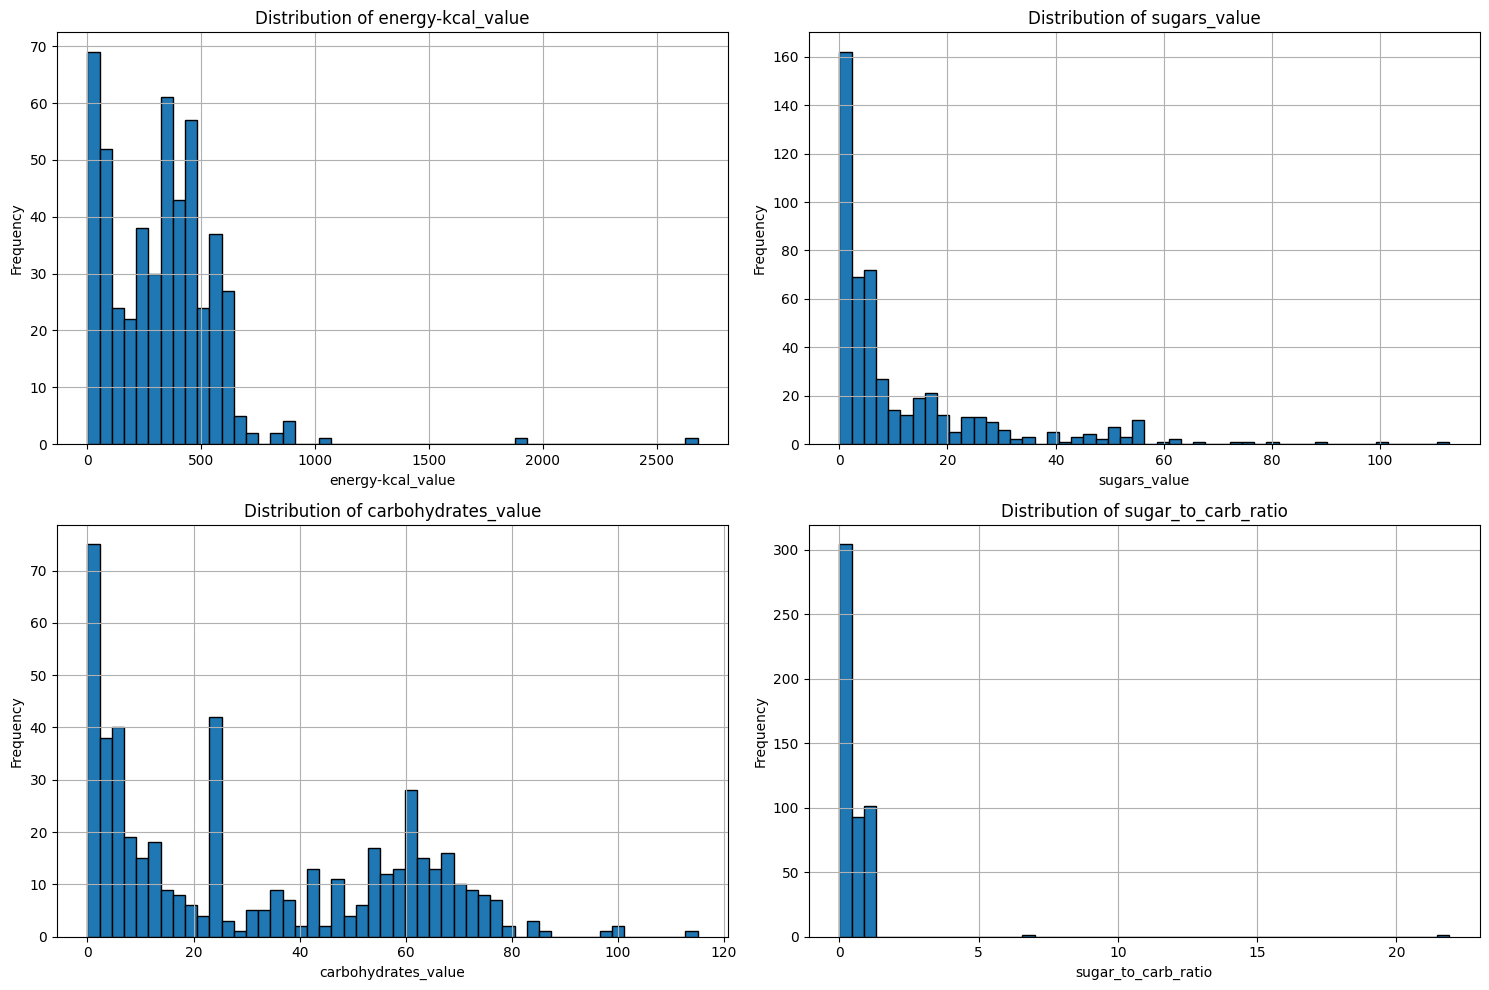

In [25]:
import matplotlib.pyplot as plt

selected_columns = ['energy-kcal_value', 'sugars_value', 'carbohydrates_value', 'sugar_to_carb_ratio']

# Calculate descriptive statistics
print("Descriptive Statistics for Key Nutrient Columns:")
print(df[selected_columns].describe())

# Create histograms
plt.figure(figsize=(15, 10))

for i, col in enumerate(selected_columns):
    plt.subplot(2, 2, i + 1)
    df[col].hist(bins=50, edgecolor='black')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

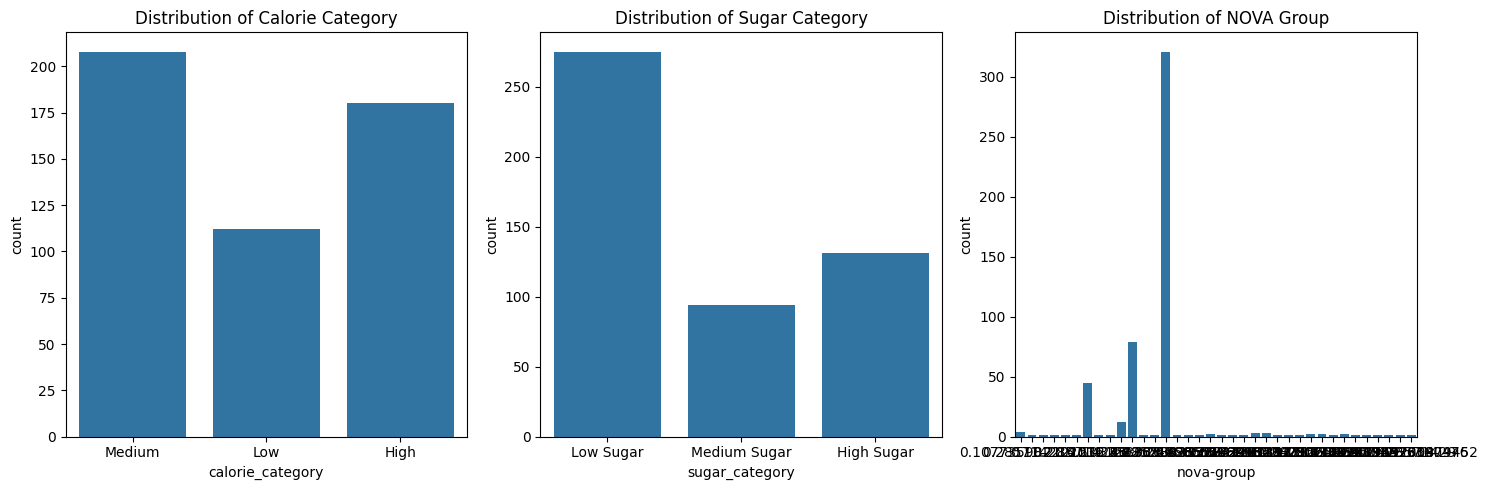

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.countplot(ax=axes[0], x='calorie_category', data=df)
axes[0].set_title('Distribution of Calorie Category')

sns.countplot(ax=axes[1], x='sugar_category', data=df)
axes[1].set_title('Distribution of Sugar Category')

sns.countplot(ax=axes[2], x='nova-group', data=df)
axes[2].set_title('Distribution of NOVA Group')

plt.tight_layout()
plt.show()

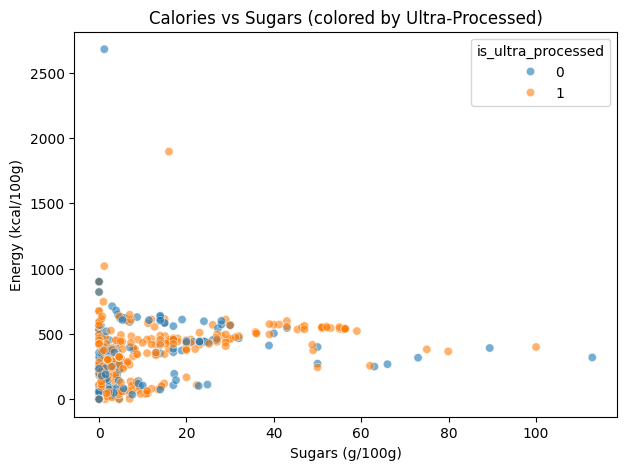

In [27]:
# Scatter: Calories vs Sugars
plt.figure(figsize=(7,5))
sns.scatterplot(x="sugars_value", y="energy-kcal_value",
                hue="is_ultra_processed", alpha=0.6, data=df)
plt.title("Calories vs Sugars (colored by Ultra-Processed)")
plt.xlabel("Sugars (g/100g)")
plt.ylabel("Energy (kcal/100g)")
plt.show()

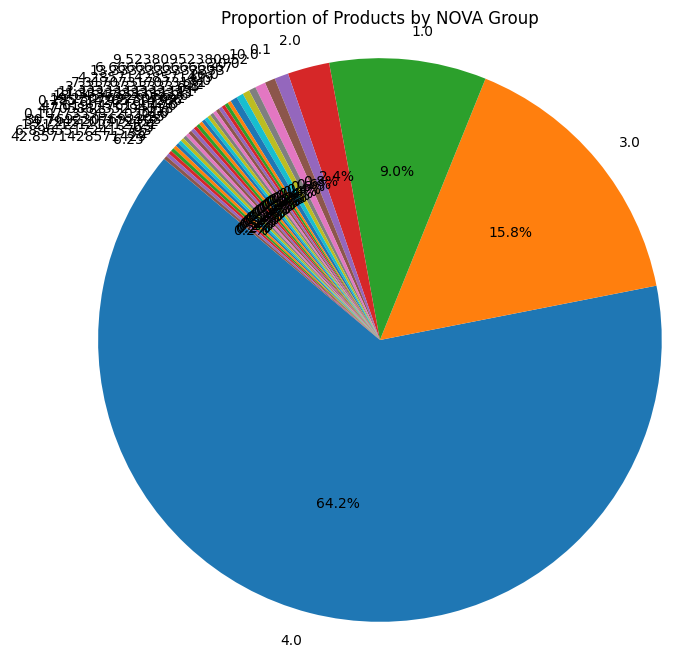

In [28]:
import matplotlib.pyplot as plt

nova_group_counts = df['nova-group'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(nova_group_counts, labels=nova_group_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Proportion of Products by NOVA Group')
plt.axis('equal')
plt.show()


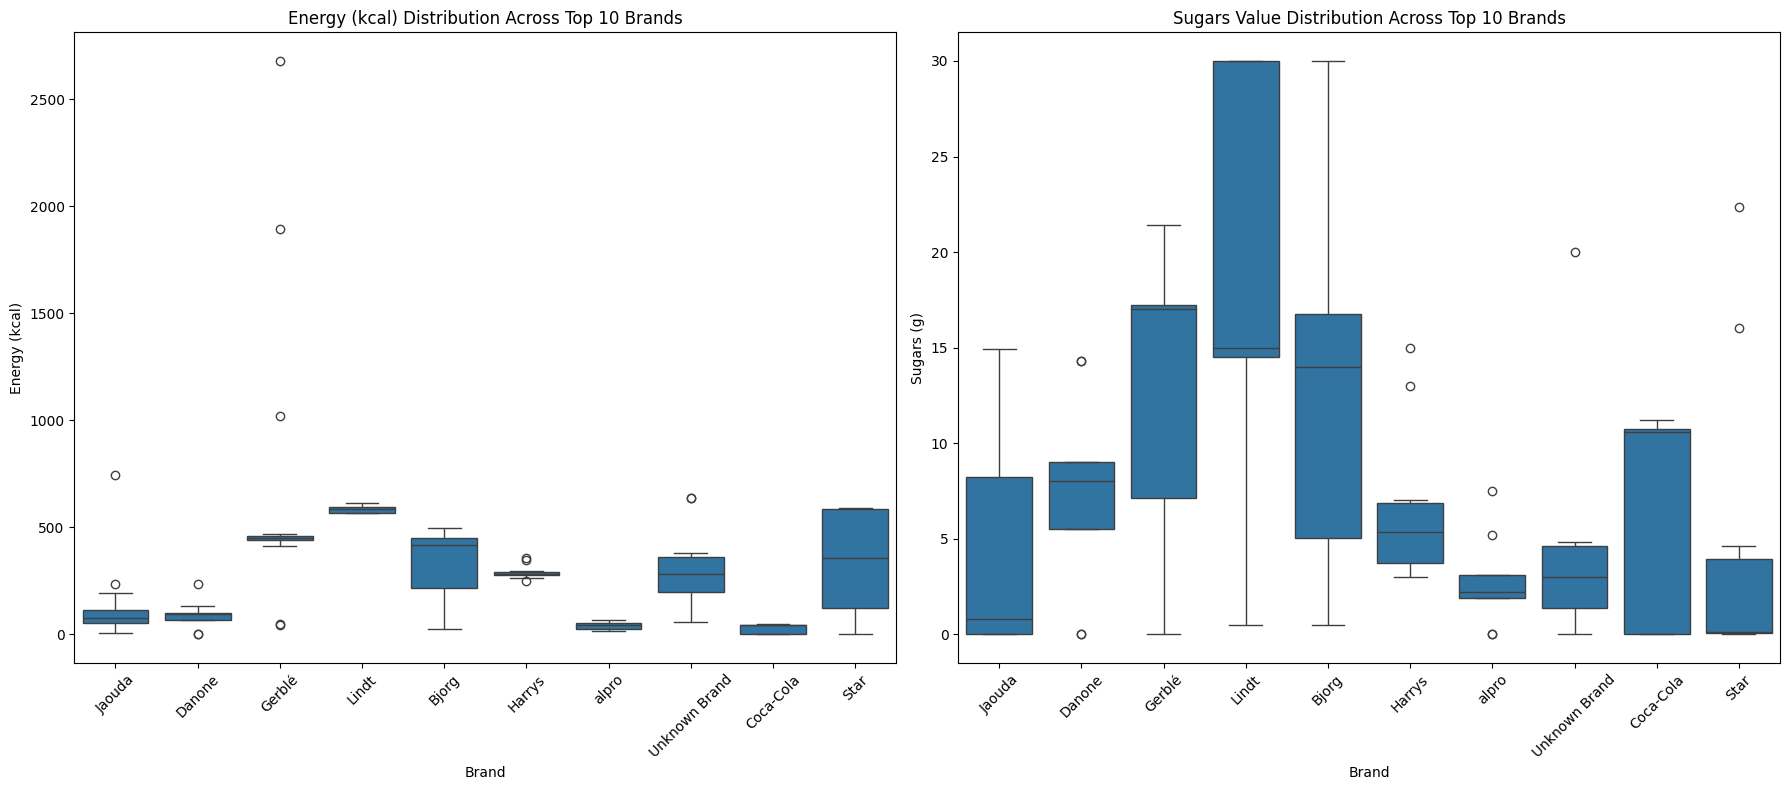

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Determine the top N brands (e.g., top 10)
n_top_brands = 10
top_brands = df['brands'].value_counts().nlargest(n_top_brands).index.tolist()

# Filter the DataFrame to include only products from these top N brands
df_top_brands = df[df['brands'].isin(top_brands)]

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Box plot for energy-kcal_value
sns.boxplot(ax=axes[0], x='brands', y='energy-kcal_value', data=df_top_brands)
axes[0].set_title(f'Energy (kcal) Distribution Across Top {n_top_brands} Brands')
axes[0].set_xlabel('Brand')
axes[0].set_ylabel('Energy (kcal)')
axes[0].tick_params(axis='x', rotation=45)

# Box plot for sugars_value
sns.boxplot(ax=axes[1], x='brands', y='sugars_value', data=df_top_brands)
axes[1].set_title(f'Sugars Value Distribution Across Top {n_top_brands} Brands')
axes[1].set_xlabel('Brand')
axes[1].set_ylabel('Sugars (g)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

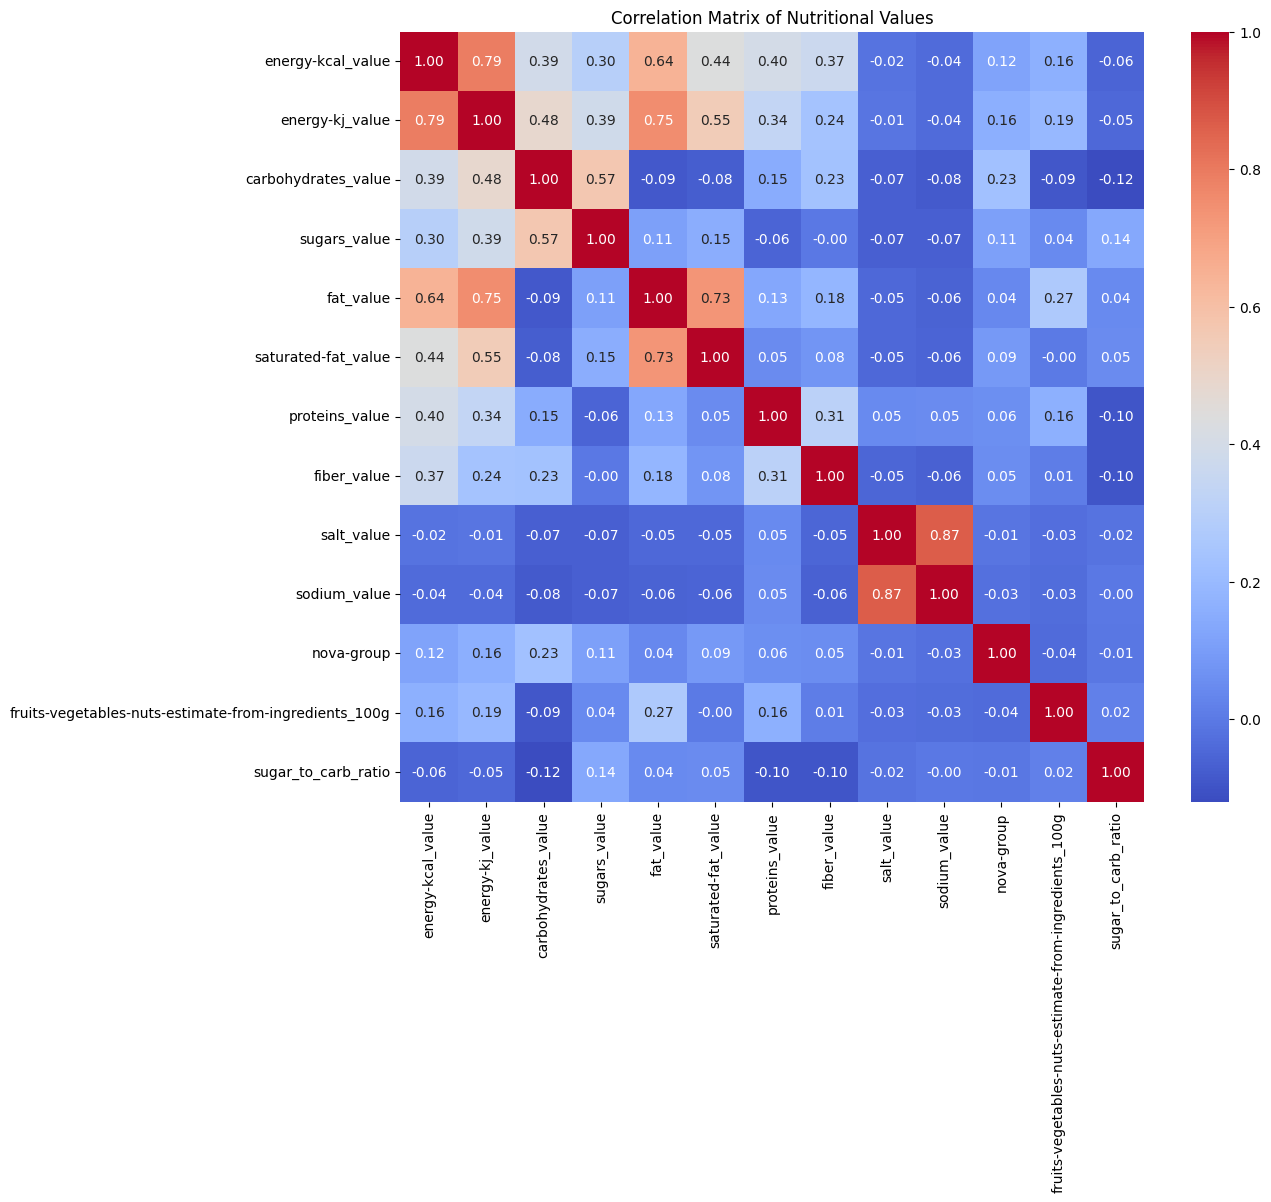

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols = [
    'energy-kcal_value',
    'energy-kj_value',
    'carbohydrates_value',
    'sugars_value',
    'fat_value',
    'saturated-fat_value',
    'proteins_value',
    'fiber_value',
    'salt_value',
    'sodium_value',
    'nova-group',
    'fruits-vegetables-nuts-estimate-from-ingredients_100g',
    'sugar_to_carb_ratio'
]

correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Nutritional Values')
plt.show()

In [32]:
df['brands']

0      Milky Food Professional
1                     سيدي علي
2                       Jaouda
3                     sidi ali
4                     Sidi Ali
                ...           
495                     Gerblé
496                     Gerblé
497                  Primevère
498                     Quaker
499                   St MÔret
Name: brands, Length: 500, dtype: object

In [33]:
df.columns

Index(['brands', 'code', 'nutriments', 'nutrition_data',
       'nutrition_data_prepared_per', 'product_name', 'nutrition_data_per',
       'nutriments_estimated', 'serving_quantity', 'nutrition_data_prepared',
       'energy-kcal_value', 'energy-kj_value', 'carbohydrates_value',
       'sugars_value', 'fat_value', 'saturated-fat_value', 'proteins_value',
       'fiber_value', 'salt_value', 'sodium_value', 'nova-group',
       'fruits-vegetables-nuts-estimate-from-ingredients_100g',
       'sugar_to_carb_ratio', 'calorie_category', 'sugar_category',
       'is_ultra_processed'],
      dtype='object')

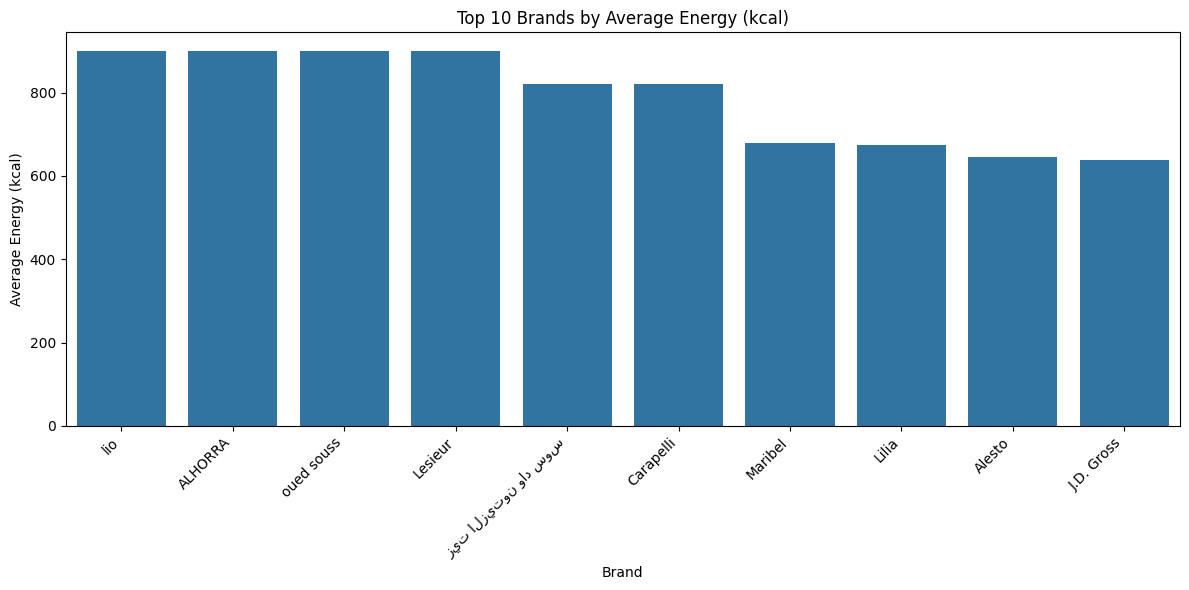

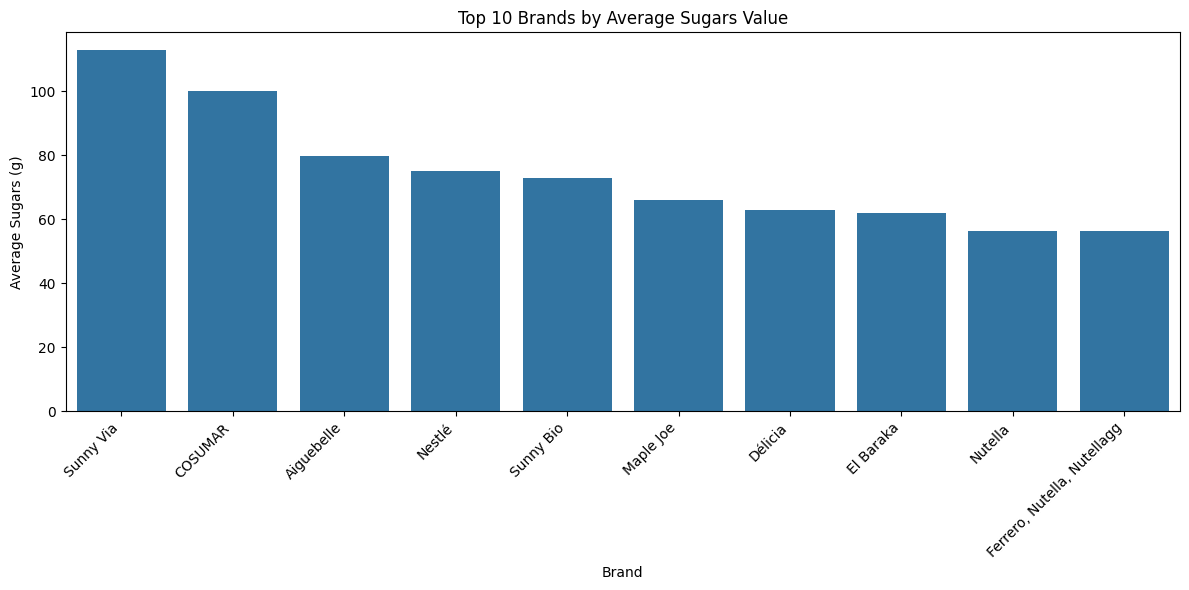

In [34]:
# Group by brands and calculate the mean for energy and sugar
brand_nutrients = df.groupby('brands')[['energy-kcal_value', 'sugars_value']].mean()

# Determine the top N brands for each nutrient
n_top_brands = 10
top_energy_brands = brand_nutrients.sort_values(by='energy-kcal_value', ascending=False).head(n_top_brands)
top_sugar_brands = brand_nutrients.sort_values(by='sugars_value', ascending=False).head(n_top_brands)

# Create bar plot for top energy brands
plt.figure(figsize=(12, 6))
sns.barplot(x=top_energy_brands.index, y='energy-kcal_value', data=top_energy_brands)
plt.title(f'Top {n_top_brands} Brands by Average Energy (kcal)')
plt.xlabel('Brand')
plt.ylabel('Average Energy (kcal)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Create bar plot for top sugar brands
plt.figure(figsize=(12, 6))
sns.barplot(x=top_sugar_brands.index, y='sugars_value', data=top_sugar_brands)
plt.title(f'Top {n_top_brands} Brands by Average Sugars Value')
plt.xlabel('Brand')
plt.ylabel('Average Sugars (g)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [37]:
!pip install mysql-connector-python

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [39]:
import mysql.connector

mydb= mysql.connector.connect(
    host="localhost",
    user="root",
    password="root",
    autocommit=True
    )
print(mydb)
mycursor=mydb.cursor()

mycursor.execute("SHOW DATABASES")
for x in mycursor:
    print(x)


('18th_sept',)
('information_schema',)
('mysql',)
('performance_schema',)
('sakila',)
('sys',)
('world',)


In [40]:
mycursor = mydb.cursor(buffered=True)

In [44]:
mycursor.execute("DROP DATABASE IF EXISTS ChocoCrunch")

In [45]:
mycursor.execute("create database Step 5: SQL Queries
📑 product_info 
Count products per brand
Count unique products per brand
Top 5 brands by product count
 Products with missing product name
 Number of unique brands
 Products with code starting with '3'

📑 nutrient_info
Top 10 products with highest energy-kcal_value
 Average sugars_value per nova-group
Count products with fat_value > 20g
Average carbohydrates_value per product
Products with sodium_value > 1g
Count products with non-zero fruits-vegetables-nuts content
Products with energy-kcal_value > 500

📑 derived_metrics
Count products per calorie_category
 Count of High Sugar products
Average sugar_to_carb_ratio for High Calorie products
 Products that are both High Calorie and High Sugar
 Number of products marked as ultra-processed
 Products with sugar_to_carb_ratio > 0.7
 Average sugar_to_carb_ratio per calorie_category

📑 Join Queries
Top 5 brands with most High Calorie products
Average energy-kcal_value for each calorie_category
Count of ultra-processed products per brand
Products with High Sugar and High Calorie along with brand
Average sugar content per brand for ultra-processed products
Number of products with fruits/vegetables/nuts content in each calorie_category
Top 5 products by sugar_to_carb_ratio with their calorie and sugar category
")

In [46]:
mycursor.execute("USE ChocoCrunch")

In [47]:
mycursor.execute("drop table if exists dervied_metric")

In [48]:
mycursor.execute("""
CREATE TABLE product_info (
    code VARCHAR(255) PRIMARY KEY,
    product_name TEXT,
    brands TEXT
);
""")
mydb.commit()


mycursor.execute("""
CREATE TABLE nutrient_info (
    code VARCHAR(255) PRIMARY KEY,
    `energy-kcal_value` REAL,
    `energy-kj_value` REAL,
    carbohydrates_value REAL,
    sugars_value REAL,
    fat_value REAL,
    `saturated-fat_value` REAL,
    proteins_value REAL,
    fiber_value REAL,
    salt_value REAL,
    sodium_value REAL,
    `fruits-vegetables-nuts-estimate-from-ingredients_100g` REAL,
    `nova-group` REAL,
    product_name TEXT,
    `nutrition-score-fr` REAL
                 
);
""")
mydb.commit()

mycursor.execute("""
CREATE TABLE derived_metrics (
    code VARCHAR(255) PRIMARY KEY,
    sugar_to_carb_ratio REAL,
    calorie_category TEXT,
    sugar_category TEXT,
    is_ultra_processed INTEGER
);
""")
mydb.commit()


In [56]:
mycursor.execute("SELECT COUNT(*) FROM product_info")
print("Product Info Rows:", mycursor.fetchone()[0])

mycursor.execute("SELECT COUNT(*) FROM nutrient_info")
print("Nutrient Info Rows:", mycursor.fetchone()[0])

mycursor.execute("SELECT COUNT(*) FROM derived_metrics")
print("Derived Metrics Rows:", mycursor.fetchone()[0])

Product Info Rows: 500
Nutrient Info Rows: 0
Derived Metrics Rows: 0


In [58]:
for _, row in df.iterrows():
    # 1. Insert into product_info
    mycursor.execute("""
        INSERT IGNORE INTO product_info (code, product_name, brands) 
        VALUES (%s, %s, %s);
    """, (row['code'], row['product_name'], row['brands']))
    
    # 2. Insert into nutrient_info (Added `nutrition-score-fr` to the columns, passed None for the missing df key)
    mycursor.execute("""
        INSERT IGNORE INTO nutrient_info (
            code, `energy-kcal_value`, `energy-kj_value`, carbohydrates_value, 
            sugars_value, fat_value, `saturated-fat_value`, proteins_value, 
            fiber_value, salt_value, sodium_value, 
            `fruits-vegetables-nuts-estimate-from-ingredients_100g`, 
            `nova-group`, product_name, `nutrition-score-fr`
        ) VALUES (%s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s);
    """, (
        row['code'], row['energy-kcal_value'], row['energy-kj_value'], row['carbohydrates_value'],
        row['sugars_value'], row['fat_value'], row['saturated-fat_value'], row['proteins_value'],
        row['fiber_value'], row['salt_value'], row['sodium_value'],
        row['fruits-vegetables-nuts-estimate-from-ingredients_100g'],
        row['nova-group'], row['product_name'], None  # <-- Changed row['nutrition-score-fr'] to None
    ))
    
    # 3. Insert into derived_metrics
    mycursor.execute("""
        INSERT IGNORE INTO derived_metrics (
            code, sugar_to_carb_ratio, calorie_category, sugar_category, is_ultra_processed
        ) VALUES (%s, %s, %s, %s, %s);
    """, (
        row['code'], row['sugar_to_carb_ratio'], row['calorie_category'], 
        row['sugar_category'], row['is_ultra_processed']
    ))

# Commit all changes once at the end of the loop
mydb.commit()
print("Data inserted successfully.")

Data inserted successfully.


# SQL Queries

📑 product_info 

In [62]:
!pip install tabulate

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [63]:
from tabulate import tabulate

In [64]:


mycursor.execute("""
    SELECT brands, COUNT(*) AS product_count
    FROM product_info
    GROUP BY brands
    ORDER BY product_count DESC
    LIMIT 50;
""")
out = mycursor.fetchall()
print(tabulate(out, headers=[i[0] for i in mycursor.description], tablefmt='psql'))

+----------------------------+-----------------+
| brands                     |   product_count |
|----------------------------+-----------------|
| Gerblé                     |              24 |
| Jaouda                     |              22 |
| Bjorg                      |              20 |
| Unknown Brand              |              12 |
| Harrys                     |              10 |
| Star                       |              10 |
| alpro                      |               9 |
| Danone                     |               9 |
| lu                         |               8 |
| La Boulangère              |               8 |
| Lindt                      |               7 |
| Coca-Cola                  |               7 |
| Fleury Michon              |               6 |
| Ferrero, Nutella           |               5 |
| Jordans                    |               5 |
| Poulain                    |               5 |
| Quaker                     |               5 |
| Barilla           

In [65]:
mycursor.execute("""
    SELECT brands, COUNT(DISTINCT product_name) AS unique_products
    FROM product_info
    GROUP BY brands;
""")
out = mycursor.fetchall()
print(tabulate(out, headers=[i[0] for i in mycursor.description], tablefmt='psql'))

+------------------------------------------------------+-------------------+
| brands                                               |   unique_products |
|------------------------------------------------------+-------------------|
|                                                      |                 3 |
| Aiguebelle                                           |                 1 |
| Ain Atlas                                            |                 3 |
| Aïn lfrane                                           |                 1 |
| aïn Saiss                                            |                 1 |
| Albane                                               |                 1 |
| Alesto                                               |                 4 |
| ALHORRA                                              |                 1 |
| alpro                                                |                 9 |
| Alter eco                                            |                 2 |

In [66]:
mycursor.execute("""
    SELECT brands, COUNT(*) AS product_count
    FROM product_info
    GROUP BY brands
    ORDER BY product_count DESC
    LIMIT 5;
""")
out = mycursor.fetchall()
print(tabulate(out, headers=[i[0] for i in mycursor.description], tablefmt='psql'))

+---------------+-----------------+
| brands        |   product_count |
|---------------+-----------------|
| Gerblé        |              24 |
| Jaouda        |              22 |
| Bjorg         |              20 |
| Unknown Brand |              12 |
| Harrys        |              10 |
+---------------+-----------------+


In [67]:
mycursor.execute("""
    SELECT *
    FROM product_info
    WHERE product_name IS NULL OR TRIM(product_name) = '';
""")
out = mycursor.fetchall()
print(tabulate(out, headers=[i[0] for i in mycursor.description], tablefmt='psql'))

+---------------+----------------+-----------+
|          code | product_name   | brands    |
|---------------+----------------+-----------|
| 6111003031107 |                | Lukus     |
| 6111032008583 |                | Gervais   |
| 6111035003523 |                | BAHIA     |
| 6111099003897 |                | lilia     |
| 6111128000460 |                | aïn Saiss |
| 6111184001197 |                | Star      |
| 6111184007618 |                | Star      |
| 6111206000696 |                | Danone    |
| 6111242100985 |                | Perly     |
| 6111246950845 |                | Jibal     |
| 6111246954461 |                | jibal     |
+---------------+----------------+-----------+


In [68]:
mycursor.execute("""
    SELECT COUNT(DISTINCT brands) AS unique_brand_count
    FROM product_info;
""")
out = mycursor.fetchall()
print(tabulate(out, headers=[i[0] for i in mycursor.description], tablefmt='psql'))

+----------------------+
|   unique_brand_count |
|----------------------|
|                  240 |
+----------------------+


In [69]:
mycursor.execute("""
    SELECT *
    FROM product_info
    WHERE code LIKE '3%';
""")
out = mycursor.fetchall()
print(tabulate(out, headers=[i[0] for i in mycursor.description], tablefmt='psql'))

+---------------+----------------------------------------------------------------------------------------------+-----------------------------------------------+
|          code | product_name                                                                                 | brands                                        |
|---------------+----------------------------------------------------------------------------------------------+-----------------------------------------------|
| 3017620421006 | Pâte à tartiner Nutella noisettes et cacao - 750g                                            | Ferrero, Nutella                              |
| 3017620422003 | Nutella                                                                                      | Nutella, Yum yum                              |
| 3017620425035 | Nutella                                                                                      | nutella                                       |
| 3017620429484 | Nutella         

📑 nutrient_info

In [70]:
mycursor.execute("""
    SELECT product_name, code, `energy-kcal_value`
    FROM nutrient_info
    ORDER BY `energy-kcal_value` DESC
    LIMIT 10;
""")
out = mycursor.fetchall()
print(tabulate(out, headers=[i[0] for i in mycursor.description], tablefmt='psql'))

+-----------------------------------------------------+---------------+---------------------+
| product_name                                        |          code |   energy-kcal_value |
|-----------------------------------------------------+---------------+---------------------|
| Levure de bière                                     | 3175680015228 |             2680    |
| Biscuits pavot citron                               | 3175681066632 |             1896    |
| Biscuits Soja Figue                                 | 3175681851863 |             1018.92 |
| Huile d'olive vierge de Maroc                       | 6111024004746 |              900    |
| Unknown Product                                     | 6111099000599 |              900    |
| Huile d'olive                                       | 6111099000254 |              900    |
| Huile de table équilibrée riche en vitamines A,E,D3 | 6111024001516 |              900    |
| Hule D'olive                                        | 6111

In [71]:
mycursor.execute("""
    SELECT `nova-group`, ROUND(AVG(sugars_value), 2) AS avg_sugars
    FROM nutrient_info
    GROUP BY `nova-group`;
""")
out = mycursor.fetchall()
print(tabulate(out, headers=[i[0] for i in mycursor.description], tablefmt='psql'))

+--------------+--------------+
|   nova-group |   avg_sugars |
|--------------+--------------|
|     3        |         8.07 |
|     4        |        12.66 |
|     1        |         4.51 |
|     3.33333  |         3    |
|    32        |        27.2  |
|     2        |        14.62 |
|    16        |        23    |
|     7.31707  |         0    |
|    10        |        21.4  |
|     0.1      |         2.3  |
|     0.4      |         0    |
|     0.285714 |       112.86 |
|     6.66667  |         9.67 |
|     4.28571  |        13    |
|     1.25     |         4.1  |
|    19.2308   |        20    |
|    47.619    |        21.43 |
|    13.3333   |        15.15 |
|     4.70588  |        24.24 |
|     9.52381  |        25.84 |
|    42.8571   |         2.86 |
|     6.25     |         1.4  |
|     1.21212  |         0    |
|    13.0435   |        40    |
|    11.1111   |        38.89 |
|     0.2      |         0    |
|     0.5      |         0    |
|     0.107736 |         4.75 |
|    30.

In [72]:
mycursor.execute("""
    SELECT COUNT(*) AS high_fat_products
    FROM nutrient_info
    WHERE fat_value > 20;
""")
out = mycursor.fetchall()
print(tabulate(out, headers=[i[0] for i in mycursor.description], tablefmt='psql'))

+---------------------+
|   high_fat_products |
|---------------------|
|                 135 |
+---------------------+


In [73]:
mycursor.execute("""
    SELECT ROUND(AVG(carbohydrates_value), 2) AS avg_carbohydrates
    FROM nutrient_info;
""")
out = mycursor.fetchall()
print(tabulate(out, headers=[i[0] for i in mycursor.description], tablefmt='psql'))

+---------------------+
|   avg_carbohydrates |
|---------------------|
|                30.9 |
+---------------------+


In [74]:
mycursor.execute("""
    SELECT product_name,code, sodium_value
    FROM nutrient_info
    WHERE sodium_value > 1;
""")
out = mycursor.fetchall()
print(tabulate(out, headers=[i[0] for i in mycursor.description], tablefmt='psql'))

+------------------------------------------------------+---------------+----------------+
| product_name                                         |          code |   sodium_value |
|------------------------------------------------------+---------------+----------------|
| Arôme MAGGI - Bouteille 250g                         | 3033710084913 |         7.32   |
| Panzani sauce pesto basilic 200g                     | 3038354199603 |         1.12   |
| Skyr                                                 | 3329770073265 |        23.603  |
| Yeast Extract                                        |      50184453 |         4.32   |
| la vache qui rit                                     | 6111028001222 |         1.3253 |
|                                                      | 6111184001197 |         2      |
| Moutarde 10.50 g                                     | 6111184001203 |         2.616  |
| Sel de table iodé                                    | 6111184001562 |        39.6    |
| flan car

In [75]:
mycursor.execute("""
    SELECT COUNT(*) AS non_zero_fvn
    FROM nutrient_info
    WHERE `fruits-vegetables-nuts-estimate-from-ingredients_100g` > 0;
""")
out = mycursor.fetchall()
print(tabulate(out, headers=[i[0] for i in mycursor.description], tablefmt='psql'))

+----------------+
|   non_zero_fvn |
|----------------|
|            180 |
+----------------+


In [76]:
mycursor.execute("""
    SELECT product_name, code, `energy-kcal_value`
    FROM nutrient_info
    WHERE `energy-kcal_value` > 500;
""")
out = mycursor.fetchall()
print(tabulate(out, headers=[i[0] for i in mycursor.description], tablefmt='psql'))

+----------------------------------------------------------------------+---------------+---------------------+
| product_name                                                         |          code |   energy-kcal_value |
|----------------------------------------------------------------------+---------------+---------------------|
| Creamy Peanut Butter                                                 | 0037600106009 |             605     |
| Poulain                                                              |      16256163 |             522     |
| Walnusskerne, angebrochen                                            |      20005733 |             712     |
| NOIR INTENSE 74% CACAO                                               |      20022464 |             570     |
| Nussmix                                                              |      20047238 |             646.667 |
| CIOCCOLATO FONDENTE                                                  |      20095291 |             544     |
|

📑 derived_metrics


In [77]:
mycursor.execute("""
    SELECT calorie_category, COUNT(*) AS product_count
    FROM derived_metrics
    GROUP BY calorie_category;
""")
out = mycursor.fetchall()
print(tabulate(out, headers=[i[0] for i in mycursor.description], tablefmt='psql'))

+--------------------+-----------------+
| calorie_category   |   product_count |
|--------------------+-----------------|
| High               |             180 |
| Medium             |             208 |
| Low                |             112 |
+--------------------+-----------------+


In [78]:
mycursor.execute("""
    SELECT COUNT(*) AS high_sugar_count
    FROM derived_metrics
    WHERE sugar_category = 'High Sugar';
""")
out = mycursor.fetchall()
print(tabulate(out, headers=[i[0] for i in mycursor.description], tablefmt='psql'))

+--------------------+
|   high_sugar_count |
|--------------------|
|                131 |
+--------------------+


In [79]:
mycursor.execute("""
    SELECT ROUND(AVG(sugar_to_carb_ratio),3) AS avg_ratio_high_calorie
    FROM derived_metrics
    WHERE calorie_category = 'High Calorie';
""")
out = mycursor.fetchall()
print(tabulate(out, headers=[i[0] for i in mycursor.description], tablefmt='psql'))

+--------------------------+
| avg_ratio_high_calorie   |
|--------------------------|
|                          |
+--------------------------+


In [80]:
mycursor.execute("""
    SELECT code, sugar_to_carb_ratio, calorie_category, sugar_category
    FROM derived_metrics
    WHERE calorie_category = 'High Calorie' AND sugar_category = 'High Sugar';
""")
out = mycursor.fetchall()
print(tabulate(out, headers=[i[0] for i in mycursor.description], tablefmt='psql'))

+--------+-----------------------+--------------------+------------------+
| code   | sugar_to_carb_ratio   | calorie_category   | sugar_category   |
|--------+-----------------------+--------------------+------------------|
+--------+-----------------------+--------------------+------------------+


In [81]:
mycursor.execute("""
    SELECT COUNT(*) AS ultra_processed_count
    FROM derived_metrics
    WHERE is_ultra_processed = 1;
""")
out = mycursor.fetchall()
print(tabulate(out, headers=[i[0] for i in mycursor.description], tablefmt='psql'))

+-------------------------+
|   ultra_processed_count |
|-------------------------|
|                     321 |
+-------------------------+


In [82]:
mycursor.execute("""
    SELECT code, sugar_to_carb_ratio
    FROM derived_metrics
    WHERE sugar_to_carb_ratio > 0.7;
""")
out = mycursor.fetchall()
print(tabulate(out, headers=[i[0] for i in mycursor.description], tablefmt='psql'))

+---------------+-----------------------+
|          code |   sugar_to_carb_ratio |
|---------------+-----------------------|
|      16256163 |              0.983333 |
|      20005733 |              0.810811 |
|      20022464 |              0.8125   |
|      20095291 |              0.852665 |
|      20724696 |              1        |
| 3017620421006 |              0.97913  |
| 3017620422003 |              0.97913  |
| 3017620425035 |              0.97913  |
| 3017620429484 |              0.97913  |
| 3021769505602 |              0.916667 |
| 3033491451652 |              1        |
| 3045140105502 |              0.964912 |
| 3046920010047 |              0.708333 |
| 3046920021043 |              0.857143 |
| 3046920022651 |              0.857143 |
| 3046920027885 |              0.903846 |
| 3046920028004 |              0.857143 |
| 3046920029681 |              0.736842 |
| 3046920029780 |              0.878788 |
| 3073781131888 |              1        |
| 3073781131925 |              1  

In [83]:
mycursor.execute("""
    SELECT calorie_category, ROUND(AVG(sugar_to_carb_ratio), 3) AS avg_ratio
    FROM derived_metrics
    GROUP BY calorie_category;
""")
out = mycursor.fetchall()
print(tabulate(out, headers=[i[0] for i in mycursor.description], tablefmt='psql'))

+--------------------+-------------+
| calorie_category   |   avg_ratio |
|--------------------+-------------|
| High               |       0.501 |
| Medium             |       0.35  |
| Low                |       0.72  |
+--------------------+-------------+


In [84]:
print("--- PRODUCT INFO METRICS ---")

# 1. Count products per brand & 2. Count unique products per brand (grouped)
mycursor.execute("""
    SELECT brands, COUNT(code) AS total_products, COUNT(DISTINCT product_name) AS unique_products 
    FROM product_info 
    WHERE brands IS NOT NULL AND brands != ''
    GROUP BY brands 
    ORDER BY total_products DESC;
""")
print("\n[Products and Unique Products per Brand]:")
print(tabulate(mycursor.fetchall(), headers=[i[0] for i in mycursor.description], tablefmt='psql'))

# 3. Top 5 brands by product count
mycursor.execute("""
    SELECT brands, COUNT(code) AS product_count 
    FROM product_info 
    WHERE brands IS NOT NULL AND brands != ''
    GROUP BY brands 
    ORDER BY product_count DESC 
    LIMIT 5;
""")
print("\n[Top 5 Brands by Product Count]:")
print(tabulate(mycursor.fetchall(), headers=[i[0] for i in mycursor.description], tablefmt='psql'))

# 4. Products with missing product name
mycursor.execute("""
    SELECT code, brands FROM product_info 
    WHERE product_name IS NULL OR product_name = '' OR product_name = 'nan';
""")
print("\n[Products with Missing Product Name]:")
print(tabulate(mycursor.fetchall(), headers=[i[0] for i in mycursor.description], tablefmt='psql'))

# 5. Number of unique brands
mycursor.execute("SELECT COUNT(DISTINCT brands) AS unique_brand_count FROM product_info WHERE brands IS NOT NULL;")
print("\n[Number of Unique Brands]:")
print(tabulate(mycursor.fetchall(), headers=[i[0] for i in mycursor.description], tablefmt='psql'))

# 6. Products with code starting with '3'
mycursor.execute("SELECT code, product_name, brands FROM product_info WHERE code LIKE '3%';")
print("\n[Products with Code Starting with '3' (Sample)]:")
print(tabulate(mycursor.fetchmany(10), headers=[i[0] for i in mycursor.description], tablefmt='psql'))

--- PRODUCT INFO METRICS ---

[Products and Unique Products per Brand]:
+------------------------------------------------------+------------------+-------------------+
| brands                                               |   total_products |   unique_products |
|------------------------------------------------------+------------------+-------------------|
| Gerblé                                               |               24 |                23 |
| Jaouda                                               |               22 |                22 |
| Bjorg                                                |               20 |                20 |
| Unknown Brand                                        |               12 |                11 |
| Harrys                                               |               10 |                10 |
| Star                                                 |               10 |                 9 |
| alpro                                                |        

In [85]:
print("--- NUTRIENT INFO METRICS ---")

# 1. Top 10 products with highest energy-kcal_value
mycursor.execute("""
    SELECT code, product_name, `energy-kcal_value` 
    FROM nutrient_info 
    ORDER BY `energy-kcal_value` DESC 
    LIMIT 10;
""")
print("\n[Top 10 Products with Highest Calories]:")
print(tabulate(mycursor.fetchall(), headers=[i[0] for i in mycursor.description], tablefmt='psql'))

# 2. Average sugars_value per nova-group
mycursor.execute("""
    SELECT `nova-group`, ROUND(AVG(sugars_value), 2) AS avg_sugar 
    FROM nutrient_info 
    WHERE `nova-group` IS NOT NULL 
    GROUP BY `nova-group`;
""")
print("\n[Average Sugar per NOVA Group]:")
print(tabulate(mycursor.fetchall(), headers=[i[0] for i in mycursor.description], tablefmt='psql'))

# 3. Count products with fat_value > 20g
mycursor.execute("SELECT COUNT(*) AS high_fat_count FROM nutrient_info WHERE fat_value > 20;")
print("\n[Count of Products with Fat > 20g]:")
print(tabulate(mycursor.fetchall(), headers=[i[0] for i in mycursor.description], tablefmt='psql'))

# 4. Average carbohydrates_value per product
mycursor.execute("SELECT ROUND(AVG(carbohydrates_value), 2) AS avg_carbs FROM nutrient_info;")
print("\n[Average Carbohydrates across All Products]:")
print(tabulate(mycursor.fetchall(), headers=[i[0] for i in mycursor.description], tablefmt='psql'))

# 5. Products with sodium_value > 1g
mycursor.execute("SELECT code, product_name, sodium_value FROM nutrient_info WHERE sodium_value > 1;")
print("\n[Products with Sodium > 1g]:")
print(tabulate(mycursor.fetchall(), headers=[i[0] for i in mycursor.description], tablefmt='psql'))

# 6. Count products with non-zero fruits-vegetables-nuts content
mycursor.execute("""
    SELECT COUNT(*) AS non_zero_fruits_veg 
    FROM nutrient_info 
    WHERE `fruits-vegetables-nuts-estimate-from-ingredients_100g` > 0;
""")
print("\n[Count of Products with Fruit/Vegetable/Nut content]:")
print(tabulate(mycursor.fetchall(), headers=[i[0] for i in mycursor.description], tablefmt='psql'))

# 7. Products with energy-kcal_value > 500
mycursor.execute("SELECT code, product_name, `energy-kcal_value` FROM nutrient_info WHERE `energy-kcal_value` > 500;")
print("\n[Products with Calories > 500 (Sample)]:")
print(tabulate(mycursor.fetchmany(10), headers=[i[0] for i in mycursor.description], tablefmt='psql'))

--- NUTRIENT INFO METRICS ---

[Top 10 Products with Highest Calories]:
+---------------+-----------------------------------------------------+---------------------+
|          code | product_name                                        |   energy-kcal_value |
|---------------+-----------------------------------------------------+---------------------|
| 3175680015228 | Levure de bière                                     |             2680    |
| 3175681066632 | Biscuits pavot citron                               |             1896    |
| 3175681851863 | Biscuits Soja Figue                                 |             1018.92 |
| 6111024004746 | Huile d'olive vierge de Maroc                       |              900    |
| 6111099000599 | Unknown Product                                     |              900    |
| 6111099000254 | Huile d'olive                                       |              900    |
| 6111024001516 | Huile de table équilibrée riche en vitamines A,E,D3 |           

In [86]:
print("--- RELATIONAL JOIN METRICS ---")

# 1. Top 5 brands with most High Calorie products
mycursor.execute("""
    SELECT p.brands, COUNT(p.code) AS high_calorie_count
    FROM product_info p
    JOIN derived_metrics d ON p.code = d.code
    WHERE d.calorie_category = 'High' AND p.brands IS NOT NULL AND p.brands != ''
    GROUP BY p.brands
    ORDER BY high_calorie_count DESC
    LIMIT 5;
""")
print("\n[Top 5 Brands with Most High-Calorie Products]:")
print(tabulate(mycursor.fetchall(), headers=[i[0] for i in mycursor.description], tablefmt='psql'))

# 2. Average energy-kcal_value for each calorie_category
mycursor.execute("""
    SELECT d.calorie_category, ROUND(AVG(n.`energy-kcal_value`), 2) AS avg_calories
    FROM nutrient_info n
    JOIN derived_metrics d ON n.code = d.code
    GROUP BY d.calorie_category;
""")
print("\n[Average Calories per Calorie Category]:")
print(tabulate(mycursor.fetchall(), headers=[i[0] for i in mycursor.description], tablefmt='psql'))

# 3. Count of ultra-processed products per brand
mycursor.execute("""
    SELECT p.brands, COUNT(p.code) AS ultra_processed_count
    FROM product_info p
    JOIN derived_metrics d ON p.code = d.code
    WHERE d.is_ultra_processed = 1 AND p.brands IS NOT NULL AND p.brands != ''
    GROUP BY p.brands
    ORDER BY ultra_processed_count DESC;
""")
print("\n[Ultra-Processed Product Count per Brand (Top Results)]:")
print(tabulate(mycursor.fetchmany(10), headers=[i[0] for i in mycursor.description], tablefmt='psql'))

# 4. Products with High Sugar and High Calorie along with brand
mycursor.execute("""
    SELECT p.code, p.product_name, p.brands
    FROM product_info p
    JOIN derived_metrics d ON p.code = d.code
    WHERE d.calorie_category = 'High' AND d.sugar_category = 'High';
""")
print("\n[Products That Are Both High Calorie and High Sugar (Sample)]:")
print(tabulate(mycursor.fetchmany(10), headers=[i[0] for i in mycursor.description], tablefmt='psql'))

# 5. Average sugar content per brand for ultra-processed products
mycursor.execute("""
    SELECT p.brands, ROUND(AVG(n.sugars_value), 2) AS avg_sugar
    FROM product_info p
    JOIN nutrient_info n ON p.code = n.code
    JOIN derived_metrics d ON p.code = d.code
    WHERE d.is_ultra_processed = 1 AND p.brands IS NOT NULL AND p.brands != ''
    GROUP BY p.brands
    ORDER BY avg_sugar DESC;
""")
print("\n[Average Sugar Content for Ultra-Processed items by Brand (Top Results)]:")
print(tabulate(mycursor.fetchmany(10), headers=[i[0] for i in mycursor.description], tablefmt='psql'))

# 6. Number of products with fruits/vegetables/nuts content in each calorie_category
mycursor.execute("""
    SELECT d.calorie_category, COUNT(n.code) AS product_count
    FROM nutrient_info n
    JOIN derived_metrics d ON n.code = d.code
    WHERE n.`fruits-vegetables-nuts-estimate-from-ingredients_100g` > 0
    GROUP BY d.calorie_category;
""")
print("\n[Products with Fruit/Vegetable/Nut Content per Calorie Category]:")
print(tabulate(mycursor.fetchall(), headers=[i[0] for i in mycursor.description], tablefmt='psql'))

# 7. Top 5 products by sugar_to_carb_ratio with their calorie and sugar category
mycursor.execute("""
    SELECT p.product_name, d.sugar_to_carb_ratio, d.calorie_category, d.sugar_category
    FROM product_info p
    JOIN derived_metrics d ON p.code = d.code
    ORDER BY d.sugar_to_carb_ratio DESC
    LIMIT 5;
""")
print("\n[Top 5 Products by Sugar-to-Carb Ratio with Categories]:")
print(tabulate(mycursor.fetchall(), headers=[i[0] for i in mycursor.description], tablefmt='psql'))

--- RELATIONAL JOIN METRICS ---

[Top 5 Brands with Most High-Calorie Products]:
+------------------+----------------------+
| brands           |   high_calorie_count |
|------------------+----------------------|
| Gerblé           |                   22 |
| Bjorg            |                   10 |
| Lindt            |                    7 |
| Ferrero, Nutella |                    5 |
| lu               |                    5 |
+------------------+----------------------+

[Average Calories per Calorie Category]:
+--------------------+----------------+
| calorie_category   |   avg_calories |
|--------------------+----------------|
| High               |         547.3  |
| Medium             |         269.98 |
| Low                |          37.84 |
+--------------------+----------------+

[Ultra-Processed Product Count per Brand (Top Results)]:
+---------------+-------------------------+
| brands        |   ultra_processed_count |
|---------------+-------------------------|
| Gerblé   

In [87]:
pip install streamlit mysql-connector-python pandas plotly

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ------------------- -------------------- 4.7/9.9 MB 25.9 MB/s eta 0:00:01
   ------------------------------------ --- 8.9/9.9 MB 25.2 MB/s eta 0:00:01
   ---------------------------------------- 9.9/9.9 MB 22.1 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip
